### 0. Data Preparation &  Importing necessary libraries
Data Preparation Notes To ensure accurate analysis and avoid double counting, the dataset "Cleaned Generation of Waste_0.csv" was filtered to include only rows where: The category column contains "Total waste", and The hazard column contains "Total" This step guarantees that only aggregated values are considered, preventing duplication from sub-category entries. Regarding missing values, all NaN values were replaced with 0. This approach was chosen to maintain continuity in statistical computations, as some economic activities may not generate waste in certain years. Treating missing values as zero ensures these cases are properly represented without disrupting analysis. Overall, these preprocessing steps improve data consistency, reliability, and interpretability for subsequent analysis.

Also in this section, we filter the data to focus on the 'Total waste' category to avoid double counting and calculate the central tendency measures


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import matplotlib.image as mpimg


# Load the dataset 
df = pd.read_csv('Cleaned Generation of Waste_0.csv')

# Filter for Total Waste to avoid double counting 
# Selecting only 'Total waste' category and 'Total' hazardousness
target_data = df[(df['Waste Category'] == 'Total waste') & (df['Hazardousness'] == 'Total')].copy()

# Fill NaN values with 0 as requested 
target_data['VALUE(Tonnes)'] = target_data['VALUE(Tonnes)'].fillna(0)
waste_values = target_data['VALUE(Tonnes)']

### 1. Descriptive Statistics
We will Calculate the summary statistics (mean, std, min, max, quartiles) to understand the distribution of the data

In [11]:
# 1. Descriptive Statistics
print("Descriptive Statistics for Total Waste")

# Displaying summary statistics (count, mean, std, min, max, etc.) using pandas describe() function.
print(waste_values.describe())

Descriptive Statistics for Total Waste
count    1.980000e+02
mean     1.969265e+06
std      4.365415e+06
min      0.000000e+00
25%      9.065225e+04
50%      3.189780e+05
75%      1.727194e+06
max      2.959918e+07
Name: VALUE(Tonnes), dtype: float64


### 2. Percentiles & IQR
We calculate the 25th and 75th percentiles to understand the distribution spread and the Interquartile Range (IQR).
#### Definitions
  

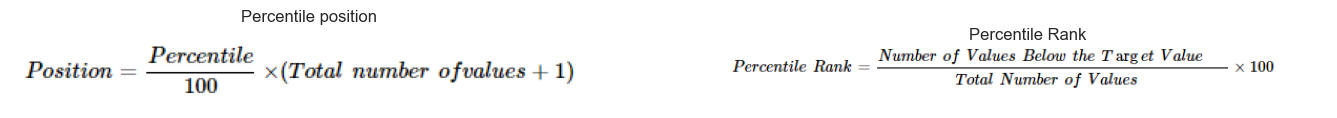

In [12]:
# Loading two images related to the Percentile rank and its position
Percentile_position  = mpimg.imread('Find_a_Specific_Percentile.png')
Percentile_Rank = mpimg.imread('Percentile_Rank.png')


# Creating a figure with 1 row and 2 columns for side-by-side
fig, axes = plt.subplots(1, 2, figsize=(17, 12))

# Displaying the first image (Percentile Position)
axes[0].imshow(Percentile_position)
axes[0].set_title("Percentile position")
axes[0].axis("off")

# Displaying the second image (Position Rank)
axes[1].imshow(Percentile_Rank)
axes[1].set_title("Percentile Rank")
axes[1].axis("off")

plt.show()

#### Applications

In [13]:
# Calculating Q1, Q3 and IQR (Interquartile Range)
q1 = np.percentile(waste_values, 25)
q3 = np.percentile(waste_values, 75)
iqr = q3 - q1

print(f"25th Percentile (Q1): {q1}")
print(f"75th Percentile (Q3): {q3}")
print(f"Interquartile Range (IQR): {iqr}")

25th Percentile (Q1): 90652.25
75th Percentile (Q3): 1727194.5
Interquartile Range (IQR): 1636542.25


### 3. Outlier Detection
Using the IQR method, we identify extreme values that might represent exceptionally high waste-producing sectors.


In [14]:
# Define bounds for outliers 
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# this line checks which values fall outside these bounds (waste_values < lower_bound) or (waste_values > upper_bound)
outliers = waste_values[(waste_values < lower_bound) | (waste_values > upper_bound)]

print(f"Number of Outliers detected: {len(outliers)}")
print(f"Upper Bound Limit: {upper_bound}")

Number of Outliers detected: 17
Upper Bound Limit: 4182007.875


### 4. Probability Functions (PDF (the Probability Density Function)   &     CDF(the cumulative distribution function )) 
We visualize the Probability Density Function (PDF) and Cumulative Distribution Function (CDF) to see the probability of specific waste amounts.

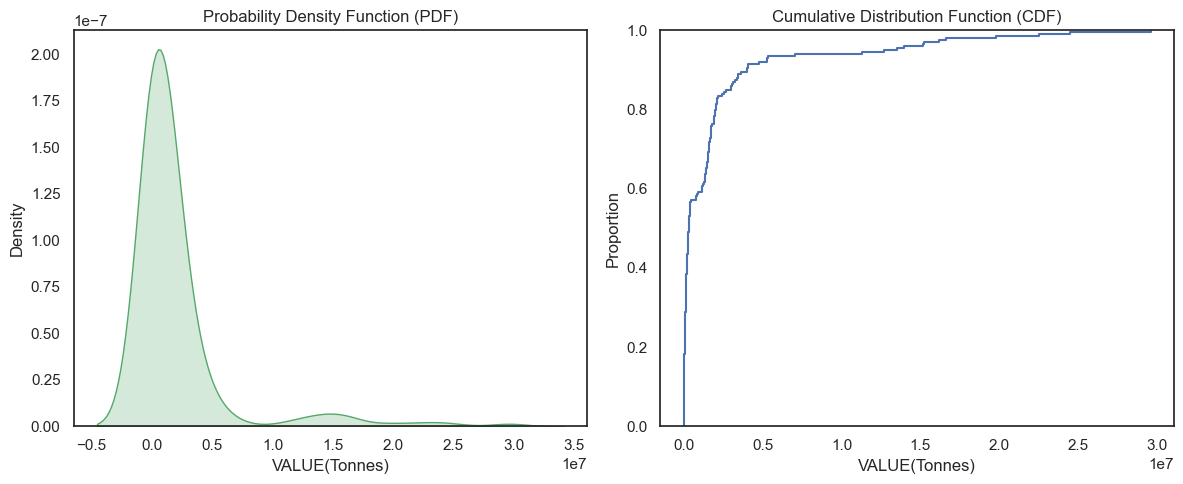

In [15]:
# Setting plot style
sns.set(style="white")
plt.figure(figsize=(12, 5))

# Plotting the Probability Density Function (PDF)
plt.subplot(1, 2, 1)
sns.kdeplot(waste_values, fill=True, color="g")
plt.title("Probability Density Function (PDF)")

# Plotting the cumulative distribution function (CDF)
plt.subplot(1, 2, 2)
sns.ecdfplot(waste_values, color="b")
plt.title("Cumulative Distribution Function (CDF)")

plt.tight_layout()
plt.show()

### 5. Probability Distributions
Checking if the waste distribution follows a Normal Distribution, which is crucial for future AI model assumptions.


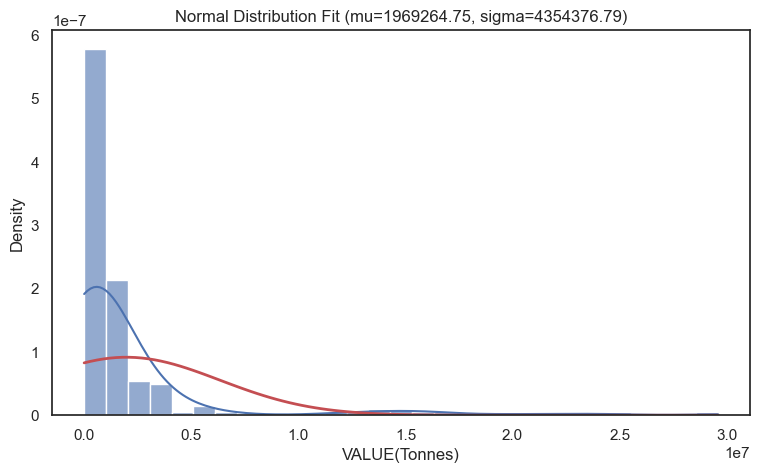

In [16]:
# Fit a normal distribution to the dataset by estimating mean (mu) and standard deviation (sigma)

mu, sigma = stats.norm.fit(waste_values)

# Creation a figure for visualization
plt.figure(figsize=(9, 5))


# Plot histogram of the data with KDE (Kernel Density Estimation)
sns.histplot(waste_values, kde=True, stat="density", alpha=0.6)


# Generate x values across the range of the dataset
x = np.linspace(waste_values.min(), waste_values.max(), 100)


# Computation of the normal probability density function (PDF)
p = stats.norm.pdf(x, mu, sigma)

# Overlay the normal distribution curve on the histogram
plt.plot(x, p, 'r', linewidth=2)


# Adding the title showing estimated parameters of normal distribution (mu and sigma)
plt.title(f"Normal Distribution Fit (mu={mu:.2f}, sigma={sigma:.2f})")
# Displaying the final plot
plt.show()

### 6. Central Limit Theorem (CLT)
Demonstrating that the means of random samples will follow a normal distribution, regardless of the original data shape.


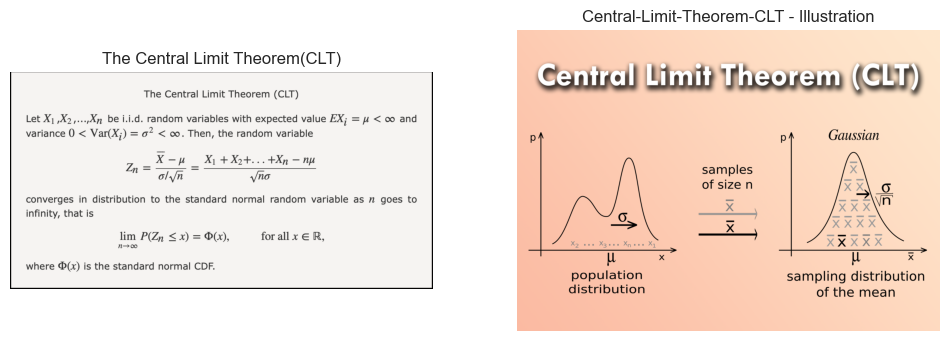

In [17]:

# Loading two images related to the Central Limit Theorem (CLT)
img1 = mpimg.imread('The Central Limit Theorem(CLT).png')
img2 = mpimg.imread('Central-Limit-Theorem-CLT illustration.png')


# Creating a figure with 1 row and 2 columns for side-by-side.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Displaying the first image (CLT concept)
axes[0].imshow(img1)
axes[0].set_title("The Central Limit Theorem(CLT)")
axes[0].axis("off")

# Displaying the second image (CLT illustration)
axes[1].imshow(img2)
axes[1].set_title("Central-Limit-Theorem-CLT - Illustration")
axes[1].axis("off")

plt.show()

### 7. The Central Limit Theorem: Distribution of Sample Means 
- Demonstration of the Central Limit Theorem Using Programming

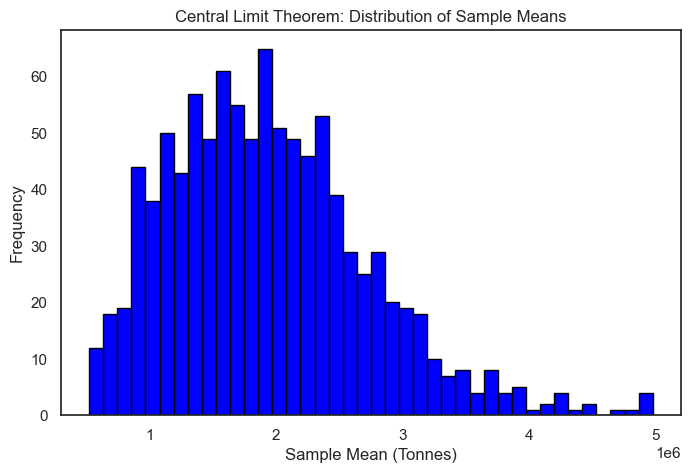

In [18]:
# Create sample means to demonstrate CLT 
# Initialize an empty list to store the mean of each sample
sample_means = []

# Define the number of samples to generate
n_samples = 1000

# Define the size of each random sample
sample_size = 30 # Taking 30 random records per sample


# Generation multiple random samples and colculate their means
for j in range(n_samples):    
    # Randomly select 'sample_size' values from the dataset
    sample = np.random.choice(waste_values, size=sample_size)
    # Calculation the mean of the selected sample
    sample_means.append(np.mean(sample))

# Creation a figure for visualization of the sample distribution
plt.figure(figsize=(8, 5))
# Plotting histogram of sample means
plt.hist(sample_means, bins=40, color='blue', edgecolor='black')

# Adding a title whivh explain the Central Limit Theorem visualization
plt.title("Central Limit Theorem: Distribution of Sample Means")

# Labeling the x-axis (mean values of samples)
plt.xlabel("Sample Mean (Tonnes)")

# Labeling the y-axis (frequency of occurrence)
plt.ylabel("Frequency")

# Displaying the final plot
plt.show()

## Reference 

- Introduction to Probability, Statistics, and Random Processes - Hossein Pishro-Nik 
- Tutorials of Course of CCT.
- https://www.theknowledgeacademy.com/blog/what-is-percentile/
- www.google.com
- https://moodle.cct.ie/course/
- Probability Mass function, Probability density function, Probability Cumulative function File(PDF_CCT)
- Probability Mass function, Probability density function, Probability Cumulative function File(IPYNB_CCT)
- percentage, percentile, Interquartile Range, Outlier detection(IPYNB_CCT))
- percentage, percentile, Interquartile Range, Outlier detection(PDF_CCT Course))
- Descriptive statistics using Python(IPYNB_CCT)
- www.qwen.ie ( using for showing the image (knowledge of matplotlib.image library))